In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from backtesting import Strategy, Backtest

def fetch_h4(symbol: str, start: str = None, period: str = "730d") -> pd.DataFrame:
    if start is not None:
        raw = yf.download(symbol, start=start, interval="60m", auto_adjust=True, progress=False)
    else:
        raw = yf.download(symbol, period=period, interval="60m", auto_adjust=True, progress=False)
    if raw.empty:
        raise RuntimeError(f"No data returned for {symbol}.")
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw = raw.rename(columns=str.lower)
    raw = raw[["open", "high", "low", "close", "volume"]]
    h4 = raw.resample("4h").agg(
        {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
    ).dropna(how="any")
    h4.index.name = "time"
    return h4

#df = fetch_h4("")
#print(df.shape)

c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

In [2]:
def sma(series, length):
    return series.rolling(window=length, min_periods=length).mean()

def ema(series, length):
    return series.ewm(span=length, adjust=False, min_periods=length).mean()

def macd(close, fast=12, slow=26, signal=9):
    macd_line = ema(close, fast) - ema(close, slow)
    signal_line = ema(macd_line, signal)
    hist = macd_line - signal_line
    return macd_line, signal_line, hist

def true_range(high, low, close):
    prev_close = close.shift(1)
    return pd.concat([high - low, (high - prev_close).abs(), (low - prev_close).abs()], axis=1).max(axis=1)

def atr(high, low, close, length=14):
    tr = true_range(high, low, close)
    return tr.ewm(alpha=1/length, adjust=False, min_periods=length).mean()

def adx(high, low, close, length=14):
    up_move = high.diff()
    down_move = -low.diff()
    plus_dm = pd.Series(np.where((up_move > down_move) & (up_move > 0), up_move, 0.0), index=high.index)
    minus_dm = pd.Series(np.where((down_move > up_move) & (down_move > 0), down_move, 0.0), index=high.index)
    atr_wilder = true_range(high, low, close).ewm(alpha=1/length, adjust=False, min_periods=length).mean()
    plus_di = 100 * (plus_dm.ewm(alpha=1/length, adjust=False, min_periods=length).mean() / atr_wilder)
    minus_di = 100 * (minus_dm.ewm(alpha=1/length, adjust=False, min_periods=length).mean() / atr_wilder)
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    adx_line = dx.ewm(alpha=1/length, adjust=False, min_periods=length).mean()
    return plus_di, minus_di, adx_line

COMMON_START = "2024-02-20"

def build_bt_df(symbol):
    d = fetch_h4(symbol)  # uses default period="730d", always within Yahoo's limit
    d["ma_360"] = sma(d["close"], 360)
    d["ma_200"] = sma(d["close"], 200)
    d["ma_89"] = sma(d["close"], 89)
    d["ema_21"] = ema(d["close"], 21)
    d["ema_8"] = ema(d["close"], 8)
    d["macd"], d["macd_signal"], d["macd_hist"] = macd(d["close"])
    d["atr_14"] = atr(d["high"], d["low"], d["close"])
    d["plus_di"], d["minus_di"], d["adx_14"] = adx(d["high"], d["low"], d["close"])
    return d.rename(columns={"open": "Open", "high": "High", "low": "Low", "close": "Close", "volume": "Volume"})

us30_raw = build_bt_df("^DJI")
gold_raw = build_bt_df("GC=F")

# trim both to their overlapping window (indicators already computed on full history,
# so lookback like MA360 is still valid at the start of the trimmed window)
common_start = max(us30_raw.index[0], gold_raw.index[0])
common_end = min(us30_raw.index[-1], gold_raw.index[-1])

us30_bt_df = us30_raw.loc[common_start:common_end]
gold_bt_df = gold_raw.loc[common_start:common_end]

print("Common window:", common_start, "->", common_end)
print("US30 bars:", len(us30_bt_df), " Gold bars:", len(gold_bt_df))

Common window: 2024-02-26 00:00:00-05:00 -> 2026-07-17 12:00:00-04:00
US30 bars: 1373  Gold bars: 3636


In [3]:
def swing_high(high, n):
    return high.rolling(n).max().shift(1)

def swing_low(low, n):
    return low.rolling(n).min().shift(1)

class ConfluenceStrategy(Strategy):
    adx_threshold = 22
    swing_lookback = 20
    atr_sl_mult = 1.5
    atr_tp_mult = 2.5
    max_consecutive_losses = 3
    cooldown_bars = 20

    def init(self):
        d = self.data.df
        self.ma_360 = self.I(lambda: d["ma_360"], name="MA360")
        self.ma_200 = self.I(lambda: d["ma_200"], name="MA200")
        self.ema_21 = self.I(lambda: d["ema_21"], name="EMA21")
        self.ema_8 = self.I(lambda: d["ema_8"], name="EMA8")
        self.macd_line = self.I(lambda: d["macd"], name="MACD")
        self.macd_signal = self.I(lambda: d["macd_signal"], name="MACDsig")
        self.macd_hist = self.I(lambda: d["macd_hist"], name="MACDhist")
        self.adx_14 = self.I(lambda: d["adx_14"], name="ADX14")
        self.atr_14 = self.I(lambda: d["atr_14"], name="ATR14")
        self.swing_hi = self.I(lambda: swing_high(d["High"], self.swing_lookback), name="SwingHi")
        self.swing_lo = self.I(lambda: swing_low(d["Low"], self.swing_lookback), name="SwingLo")
        self._last_closed_count = 0
        self._consecutive_losses = 0
        self._cooldown_until_bar = -1

    def next(self):
        # --- circuit breaker bookkeeping ---
        closed = self.closed_trades
        if len(closed) > self._last_closed_count:
            for t in closed[self._last_closed_count:]:
                if t.pl < 0:
                    self._consecutive_losses += 1
                else:
                    self._consecutive_losses = 0
            self._last_closed_count = len(closed)
            if self._consecutive_losses >= self.max_consecutive_losses:
                self._cooldown_until_bar = len(self.data) + self.cooldown_bars
                self._consecutive_losses = 0

        in_cooldown = len(self.data) < self._cooldown_until_bar

        price = self.data.Close[-1]
        atr = self.atr_14[-1]
        if np.isnan(atr) or np.isnan(self.ma_360[-1]) or np.isnan(self.adx_14[-1]) or np.isnan(self.swing_hi[-1]):
            return

        trending = self.adx_14[-1] > self.adx_threshold
        ema_bullish = self.ema_8[-1] > self.ema_21[-1]
        ema_bearish = self.ema_8[-1] < self.ema_21[-1]
        macd_bull = self.macd_hist[-1] > 0
        macd_bear = self.macd_hist[-1] < 0
        bos_up = price > self.swing_hi[-1]
        bos_down = price < self.swing_lo[-1]
        macro_uptrend = price > self.ma_360[-1] and price > self.ma_200[-1]
        macro_downtrend = price < self.ma_360[-1] and price < self.ma_200[-1]

        long_signal = trending and macro_uptrend and ema_bullish and macd_bull and bos_up
        short_signal = trending and macro_downtrend and ema_bearish and macd_bear and bos_down

        if not self.position:
            if not in_cooldown:
                if long_signal:
                    sl = price - self.atr_sl_mult * atr
                    tp = price + self.atr_tp_mult * atr
                    if sl < price:
                        self.buy(sl=sl, tp=tp, size=0.1)
                elif short_signal:
                    sl = price + self.atr_sl_mult * atr
                    tp = price - self.atr_tp_mult * atr
                    if sl > price:
                        self.sell(sl=sl, tp=tp, size=0.1)
        else:
            if self.position.is_long and price < self.ema_21[-1] and not macro_uptrend:
                self.position.close()
            elif self.position.is_short and price > self.ema_21[-1] and not macro_downtrend:
                self.position.close()

In [4]:
def run_fold(df, train_start, train_end, test_end, cash=25_000):
    print(f"Fold: train [{train_start.date()} -> {train_end.date()}]  test [{train_end.date()} -> {test_end.date()}]")
    train_slice = df.loc[train_start:train_end]
    test_slice = df.loc[train_end:test_end]
    bt_train = Backtest(train_slice, ConfluenceStrategy, cash=cash, commission=0.0002, margin=1/30)
    opt_stats = bt_train.optimize(
        adx_threshold=range(15, 31, 5),
        swing_lookback=range(10, 41, 10),
        atr_sl_mult=[1.0, 1.5, 2.0, 2.5],
        atr_tp_mult=[1.5, 2.0, 2.5, 3.0, 3.5, 4.0],
        maximize="SQN",
        constraint=lambda p: p.atr_tp_mult > p.atr_sl_mult,
    )
    params = {k: getattr(opt_stats._strategy, k) for k in ["adx_threshold", "swing_lookback", "atr_sl_mult", "atr_tp_mult"]}
    bt_test = Backtest(test_slice, ConfluenceStrategy, cash=cash, commission=0.0002, margin=1/30)
    test_stats = bt_test.run(**params)
    print(f"  params={params}  Return={test_stats['Return [%]']:.2f}%  WinRate={test_stats['Win Rate [%]']:.1f}%  Trades={test_stats['# Trades']}")
    return params, test_stats

def walk_forward(df, cash=25_000, initial_train_months=12, test_months=3):
    data_start = df.index[0]
    data_end = df.index[-1]
    train_end = data_start + pd.DateOffset(months=initial_train_months)
    fold_results = []
    while train_end + pd.DateOffset(months=test_months) <= data_end:
        test_end = train_end + pd.DateOffset(months=test_months)
        params, test_stats = run_fold(df, data_start, train_end, test_end, cash=cash)
        fold_results.append({
            "test_end": test_end,
            "return_pct": test_stats["Return [%]"],
            "win_rate": test_stats["Win Rate [%]"],
            "num_trades": test_stats["# Trades"],
        })
        train_end = test_end
    return fold_results

In [5]:
print("=== US30 (half-capital) ===")
us30_folds = walk_forward(us30_bt_df, cash=25_000)

print("\n=== Gold (half-capital) ===")
gold_folds = walk_forward(gold_bt_df, cash=25_000)

=== US30 (half-capital) ===
Fold: train [2024-02-26 -> 2025-02-26]  test [2025-02-26 -> 2025-05-26]


C:\Users\milat\AppData\Local\Temp\ipykernel_34192\4287790439.py:5: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt_train = Backtest(train_slice, ConfluenceStrategy, cash=cash, commission=0.0002, margin=1/30)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_gri

  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(20), 'atr_sl_mult': np.float64(1.0), 'atr_tp_mult': np.float64(2.5)}  Return=8.81%  WinRate=50.0%  Trades=6
Fold: train [2024-02-26 -> 2025-05-26]  test [2025-05-26 -> 2025-08-26]


C:\Users\milat\AppData\Local\Temp\ipykernel_34192\4287790439.py:15: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt_test = Backtest(test_slice, ConfluenceStrategy, cash=cash, commission=0.0002, margin=1/30)
C:\Users\milat\AppData\Local\Temp\ipykernel_34192\4287790439.py:5: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt_train = Backtest(train_slice, ConfluenceStrategy, cash=cash, commission=0.0002, margin=1/30)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-proces

  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(20), 'atr_sl_mult': np.float64(1.0), 'atr_tp_mult': np.float64(2.5)}  Return=6.36%  WinRate=50.0%  Trades=6
Fold: train [2024-02-26 -> 2025-08-26]  test [2025-08-26 -> 2025-11-26]


c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..

  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(20), 'atr_sl_mult': np.float64(1.0), 'atr_tp_mult': np.float64(2.5)}  Return=-4.10%  WinRate=0.0%  Trades=3
Fold: train [2024-02-26 -> 2025-11-26]  test [2025-11-26 -> 2026-02-26]


c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..

  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(20), 'atr_sl_mult': np.float64(1.0), 'atr_tp_mult': np.float64(2.5)}  Return=-3.09%  WinRate=0.0%  Trades=3
Fold: train [2024-02-26 -> 2026-02-26]  test [2026-02-26 -> 2026-05-26]


C:\Users\milat\AppData\Local\Temp\ipykernel_34192\4287790439.py:15: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt_test = Backtest(test_slice, ConfluenceStrategy, cash=cash, commission=0.0002, margin=1/30)
C:\Users\milat\AppData\Local\Temp\ipykernel_34192\4287790439.py:16: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  test_stats = bt_test.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimi

  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(20), 'atr_sl_mult': np.float64(1.0), 'atr_tp_mult': np.float64(2.5)}  Return=-1.93%  WinRate=20.0%  Trades=5

=== Gold (half-capital) ===
Fold: train [2024-02-26 -> 2025-02-26]  test [2025-02-26 -> 2025-05-26]


c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..

  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(40), 'atr_sl_mult': np.float64(2.5), 'atr_tp_mult': np.float64(4.0)}  Return=18.72%  WinRate=57.1%  Trades=7
Fold: train [2024-02-26 -> 2025-05-26]  test [2025-05-26 -> 2025-08-26]


c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..

  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(10), 'atr_sl_mult': np.float64(2.5), 'atr_tp_mult': np.float64(4.0)}  Return=-12.70%  WinRate=10.0%  Trades=10
Fold: train [2024-02-26 -> 2025-08-26]  test [2025-08-26 -> 2025-11-26]


c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..

  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(10), 'atr_sl_mult': np.float64(2.5), 'atr_tp_mult': np.float64(4.0)}  Return=75.50%  WinRate=76.9%  Trades=13
Fold: train [2024-02-26 -> 2025-11-26]  test [2025-11-26 -> 2026-02-26]


c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..

  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(10), 'atr_sl_mult': np.float64(2.5), 'atr_tp_mult': np.float64(4.0)}  Return=48.14%  WinRate=70.0%  Trades=10
Fold: train [2024-02-26 -> 2026-02-26]  test [2026-02-26 -> 2026-05-26]


c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..

  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(20), 'atr_sl_mult': np.float64(2.0), 'atr_tp_mult': np.float64(4.0)}  Return=-2.79%  WinRate=37.5%  Trades=8


c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1545: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = self.run(**dict(zip(heatmap.index.names, best_params)))


   fold             us30_test_end             gold_test_end   us30_equity  \
0     1 2025-05-26 07:00:00-04:00 2025-05-26 00:00:00-04:00  27202.287481   
1     2 2025-08-26 07:00:00-04:00 2025-08-26 00:00:00-04:00  28932.962772   
2     3 2025-11-26 07:00:00-05:00 2025-11-26 00:00:00-05:00  27746.273633   
3     4 2026-02-26 07:00:00-05:00 2026-02-26 00:00:00-05:00  26889.569970   
4     5 2026-05-26 07:00:00-04:00 2026-05-26 00:00:00-04:00  26370.342567   

    gold_equity  portfolio_equity  
0  29680.012931      56882.300413  
1  25909.912612      54842.875383  
2  45472.042897      73218.316529  
3  67362.159687      94251.729657  
4  65481.611805      91851.954372  


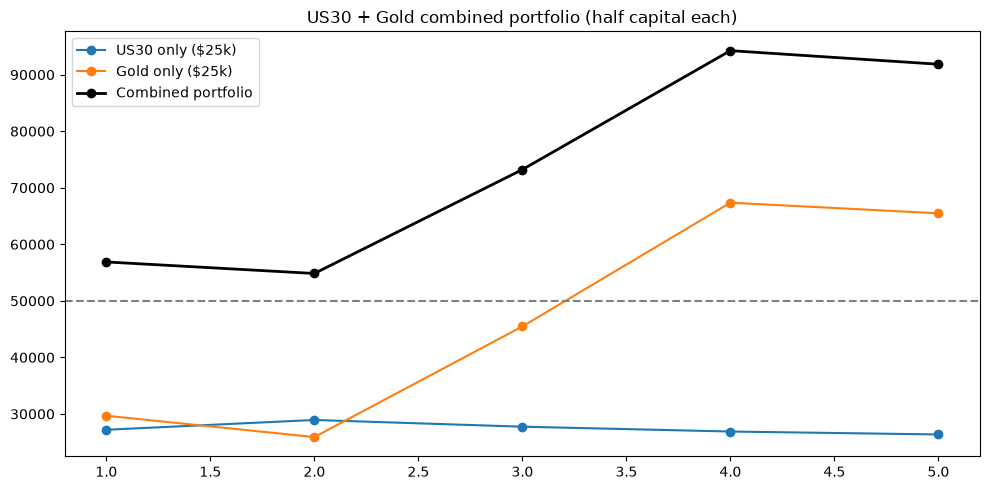

In [6]:
def compound_equity(fold_results, starting_cash=25_000):
    fold_df = pd.DataFrame(fold_results)
    equity = starting_cash
    equities = []
    for r in fold_df["return_pct"]:
        equity *= (1 + r / 100)
        equities.append(equity)
    fold_df["equity_after_fold"] = equities
    return fold_df

us30_df = compound_equity(us30_folds)
gold_df = compound_equity(gold_folds)

n_folds = min(len(us30_df), len(gold_df))
us30_df = us30_df.iloc[:n_folds].reset_index(drop=True)
gold_df = gold_df.iloc[:n_folds].reset_index(drop=True)

portfolio = pd.DataFrame({
    "fold": range(1, n_folds + 1),
    "us30_test_end": us30_df["test_end"],
    "gold_test_end": gold_df["test_end"],
    "us30_equity": us30_df["equity_after_fold"],
    "gold_equity": gold_df["equity_after_fold"],
})
portfolio["portfolio_equity"] = portfolio["us30_equity"] + portfolio["gold_equity"]
print(portfolio)

plt.figure(figsize=(10, 5))
plt.plot(portfolio["fold"], portfolio["us30_equity"], marker="o", label="US30 only ($25k)")
plt.plot(portfolio["fold"], portfolio["gold_equity"], marker="o", label="Gold only ($25k)")
plt.plot(portfolio["fold"], portfolio["portfolio_equity"], marker="o", linewidth=2, color="black", label="Combined portfolio")
plt.axhline(50_000, color="gray", linestyle="--")
plt.title("US30 + Gold combined portfolio (half capital each)")
plt.legend()
plt.tight_layout()
plt.show()